In [ ]:
import pandas as pd
import os

# 1. Load the CSV
# Using the path we established in the previous step
file_path = "/content/drive/MyDrive/transcriptions.csv"
df = pd.read_csv(file_path)

# 2. Advanced Extraction Function
def extract_label(link):
    # Convert to string and lowercase to avoid errors
    link = str(link).lower()

    # Check for specific emotions
    if 'anger' in link:
        return 'Anger'
    elif 'happy' in link:
        return 'Happy'
    elif 'sad' in link:
        return 'Sad'
    elif 'love' in link:
        return 'Love'
    # Handling the common "netural" typo in your dataset
    elif 'neutral' in link or 'netural' in link:
        return 'Neutral'

    return 'Unknown'

# 3. Apply the label
df['Label'] = df['Audio Link'].apply(extract_label)

# 4. Filter out "Unknown"
# For your thesis, you only want clean data. This removes stray files.
initial_count = len(df)
df = df[df['Label'] != 'Unknown']
print(f"Removed {initial_count - len(df)} files with unknown labels.")

# 5. Check the distribution
print("\n--- Current Data Distribution ---")
print(df['Label'].value_counts())

# 6. Save back to Drive
output_path = "/content/final_labeled_transcriptions.csv"
df.to_csv(output_path, index=False)

print(f"\nSuccess! Labeled file saved at: {output_path}")

Removed 1 files with unknown labels.

--- Current Data Distribution ---
Label
Anger      2130
Happy      1847
Neutral    1734
Sad        1701
Love       1175
Name: count, dtype: int64

Success! Labeled file saved at: /content/final_labeled_transcriptions.csv


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip uninstall transformers -y
!pip install transformers datasets evaluate accelerate -U

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 10.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import transformers
print(transformers.__version__)

5.5.4


In [ ]:
import pandas as pd

input_file = "final_labeled_transcriptions.csv"
df = pd.read_csv(input_file)

# Check exact numbers
print("--- Emotion Counts ---")
print(df['Label'].value_counts())

# Check percentages
print("\n--- Percentages ---")
print(df['Label'].value_counts(normalize=True) * 100)

--- Emotion Counts ---
Label
Anger      2130
Happy      1847
Neutral    1734
Sad        1701
Love       1175
Name: count, dtype: int64

--- Percentages ---
Label
Anger      24.804938
Happy      21.509258
Neutral    20.193315
Sad        19.809014
Love       13.683475
Name: proportion, dtype: float64


**XLM-R Fine Tuning**

In [ ]:
# ------------------- XLM-R Fine-Tuning for Urdu Text -------------------
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate
import torch

# Keep only relevant columns
df = df[['text', 'Label']]

# Encode labels
labels = list(set(df['Label']))
label_encoding = {label: idx for idx, label in enumerate(labels)}
rev_label_encoding = {v: k for k, v in label_encoding.items()}
df['Label'] = df['Label'].map(label_encoding)

# ------------------- Train/Test Split -------------------
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Convert to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)
data = DatasetDict({'train': train_dataset, 'test': test_dataset})

# ------------------- Tokenizer -------------------
model_name = "xlm-roberta-base"  # or "xlm-roberta-base" if GPU memory is small
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_datasets = data.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column("Label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
# ------------------- Model -------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=rev_label_encoding,
    label2id=label_encoding,
    ignore_mismatched_sizes=True
)

# ------------------- Metrics -------------------
metric_f1 = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'f1': metric_f1.compute(predictions=predictions, references=labels, average='macro')['f1'],
        'accuracy': metric_acc.compute(predictions=predictions, references=labels)['accuracy']
    }

# ------------------- Training Arguments -------------------
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy='epoch',
    save_strategy='epoch',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,  # Simulate a batch size of 16 (2 * 8)
    warmup_steps=500,               # Helps prevent the loss from exploding early on
    weight_decay=0.01,              # Prevents overfitting
    learning_rate=2e-5,
    per_device_eval_batch_size=2,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=True,
    logging_dir='./logs',
    logging_strategy='steps',
    logging_steps=50
)

# ------------------- Trainer -------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    compute_metrics=compute_metrics
)

# ------------------- Train & Evaluate -------------------
trainer.train()
trainer.evaluate()

# ------------------- Save Model -------------------
model.save_pretrained('./fine_tuned_xlm_roberta')
tokenizer.save_pretrained('./fine_tuned_xlm_roberta')
print("Fine-tuned XLM-R model saved successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned XLM-R model saved successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
save_path = "/content/drive/MyDrive/fine_tuned_xlm_roberta"
import os
os.makedirs(save_path, exist_ok=True)

In [ ]:
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/fine_tuned_xlm_roberta/tokenizer_config.json',
 '/content/drive/MyDrive/fine_tuned_xlm_roberta/tokenizer.json')

In [ ]:
# Re-save to ensure files are complete
model.save_pretrained('/content/drive/MyDrive/fine_tuned_xlm_roberta')
tokenizer.save_pretrained('/content/drive/MyDrive/fine_tuned_xlm_roberta')
print("Model re-saved successfully!")

NameError: name 'model' is not defined

**Embeddings From Generic XLM-RoBERTa For XGBoost**

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel

# Load the pre-trained XLM-RoBERTa model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModel.from_pretrained("xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

file_path = '/content/final_labeled_transcriptions.csv'
df = pd.read_csv(file_path)

# 1. Setup Data
# Ensure 'texts', 'links', and 'labels' are defined from your Excel load
df['Transcription'] = df['Transcription'].fillna("").astype(str)
texts = df['Transcription'].tolist()
links = df['Audio Link'].tolist()
labels = df['Label'].tolist()

# 2. Configuration & Model Load
model_name = "xlm-roberta-base"  # Using Base as requested
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

BATCH_SIZE = 32  # Base model is lighter, 32 works great on T4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 3. Optimized Batch Processing
all_embeddings = []

print(f"Starting extraction on {device}...")
for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch_texts = texts[i : i + BATCH_SIZE]

    # Tokenize the entire batch
    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        # Using the standard model call (handles pooling better)
        outputs = model(**inputs)
        # last_hidden_state shape: [batch_size, sequence_length, 768]

        # Mean Pooling: Average across the sequence length (dim=1)
        embeddings = outputs.last_hidden_state.mean(dim=1)
        all_embeddings.append(embeddings.cpu().numpy())

# 4. Finalizing Data
# Stack the list of arrays into one large numpy array
final_features = np.vstack(all_embeddings)

# Create DataFrame
embeddings_df = pd.DataFrame(final_features)
embeddings_df['Audio Link'] = links
embeddings_df['Label'] = labels

# 5. Save
# Note: I'm keeping .csv as you asked, but Parquet is better for XGBoost!
output_file = '/content/drive/MyDrive/urdu_embeddings_optimized.csv'
embeddings_df.to_csv(output_file, index=False)

print(f"Finished! Saved {final_features.shape[0]} rows with {final_features.shape[1]} features.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting extraction on cuda...


100%|██████████| 269/269 [00:28<00:00,  9.58it/s]


Finished! Saved 8587 rows with 768 features.


In [ ]:
import pandas as pd

# Load the file
output_file = 'urdu_embeddings_optimized.csv'
df_check = pd.read_csv(output_file)

# 1. Check Feature Count
total_cols = len(df_check.columns)
# Subtracting 2 because 'Audio Link' and 'Label' are metadata/target
feature_count = total_cols - 2

print(f"--- Data Report ---")
print(f"Total Rows: {len(df_check)}")
print(f"Total Features: {feature_count} (Expected: 768 for XLM-RoBERTa)")

# 2. Check for "Broken" Rows (NaNs)
nan_counts = df_check.isna().sum().sum()
if nan_counts > 0:
    print(f"⚠️ WARNING: Found {nan_counts} missing values! Check rows: {df_check[df_check.isna().any(axis=1)].index.tolist()}")
else:
    print("✅ No missing values found.")

# 3. Check Data Types
non_numeric = df_check.drop(columns=['Audio Link', 'Label']).select_dtypes(exclude=['number']).columns
if len(non_numeric) > 0:
    print(f"⚠️ WARNING: Columns {list(non_numeric)} are not numeric. XGBoost needs numbers!")
else:
    print("✅ All features are numeric.")

# Display first few rows to verify structure
print("\n--- Preview ---")
print(df_check.head())

--- Data Report ---
Total Rows: 8579
Total Features: 768 (Expected: 768 for XLM-RoBERTa)
✅ No missing values found.
✅ All features are numeric.

--- Preview ---
          0         1         2         3         4         5         6  \
0  0.019811  0.065566  0.019194  0.015445  0.026274 -0.083204 -0.006170   
1  0.026040  0.091730  0.019642 -0.018606  0.044940 -0.060689  0.004490   
2  0.017510  0.068018  0.023663 -0.039201  0.050082 -0.054586 -0.015191   
3  0.037487  0.074133  0.019126  0.011972  0.050579 -0.125136 -0.005200   
4  0.029281  0.072895  0.038389  0.026167  0.052872 -0.032992 -0.008261   

          7         8         9  ...       760       761       762       763  \
0  0.053517  0.001346  0.007101  ...  0.038264 -0.010358  0.027735 -0.031679   
1  0.018963  0.036186 -0.107772  ...  0.043187 -0.008388  0.040712 -0.051018   
2  0.045953  0.003228 -0.074174  ...  0.032635 -0.001072  0.024190 -0.060816   
3 -0.009062  0.025187 -0.051203  ...  0.042925  0.005738  0.031069 -

In [ ]:
!cp "/content/urdu_embeddings_optimized_v2.csv" "/content/drive/MyDrive/urdu_embeddings_v2.csv"

**XGBoost Model**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# Load the features from the Excel file
input_file = ("/content/drive/MyDrive/urdu_embeddings_optimized.csv")
df = pd.read_csv(input_file)
df = df.drop(columns=["Audio Link"])

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Split the data into features (X) and labels (y)
#df = df.drop(['Link'],axis = 1)
data = df.iloc[::]  # Features
Y = df['Label']      # Target variable
X = data.drop(['Label'],axis = 1)

label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Define and train the XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=500,      # Number of boosting rounds (trees)
    tree_method="hist",
    learning_rate=0.05,     # Learning rate for boosting
    max_depth=8,           # Maximum depth of trees
    subsample=0.8,              # Use 80% of data for each tree (prevents overfitting)
    colsample_bytree=0.8,
    device="cuda",              # Run XGBoost on your T4 GPU for speed
    eval_metric='mlogloss', # Log loss for multi-class classification
    use_label_encoder=False # Disable automatic label encoding
)

# Train the XGBoost classifier on the extracted features and corresponding labels
xgb_model.fit(X_train, Y_train)

y_pred = xgb_model.predict(X_test)

# Calculate test accuracy
accuracy = accuracy_score(Y_test, y_pred)
print(f"XGBoost Test Accuracy: {accuracy * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:58:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Accuracy: 40.57%


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [06:00:19] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



--- Detailed Classification Report ---
              precision    recall  f1-score   support

       Anger       0.40      0.56      0.46       428
       Happy       0.40      0.44      0.42       355
        Love       0.44      0.20      0.28       243
     Neutral       0.38      0.37      0.38       347
         Sad       0.44      0.36      0.39       345

    accuracy                           0.41      1718
   macro avg       0.41      0.39      0.39      1718
weighted avg       0.41      0.41      0.40      1718


--- Confusion Matrix ---


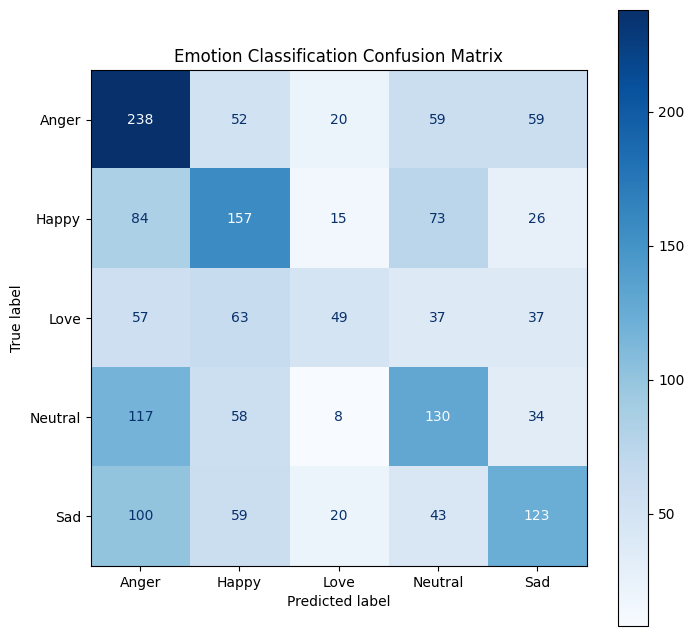

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Print detailed report (Precision, Recall, F1 for EACH emotion)
print("\n--- Detailed Classification Report ---")
# Use label_encoder.classes_ to show actual names like 'anger', 'happy'
print(classification_report(Y_test, y_pred, target_names=label_encoder.classes_))

# 2. Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(Y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Emotion Classification Confusion Matrix')
plt.show()

**Embeddings from fine tuned XLM-robert**

In [ ]:
# Instead of "xlm-roberta-base"
model_name = "/content/drive/MyDrive/fine_tuned_xlm_roberta"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: /content/drive/MyDrive/fine_tuned_xlm_roberta
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

file_path = 'labeled_file.csv'
df = pd.read_csv(file_path)

# 1. Setup Data
# Ensure 'texts', 'links', and 'labels' are defined from your Excel load
texts = df['text'].tolist()
links = df['Link'].tolist()
labels = df['Label'].tolist()

# 2. Configuration & Model Load
model_name = "/content/drive/MyDrive/fine_tuned_xlm_roberta"  # Using fine tuned xlmroberta as requested
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

BATCH_SIZE = 32  # Base model is lighter, 32 works great on T4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 3. Optimized Batch Processing
all_embeddings = []

print(f"Starting extraction on {device}...")
for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch_texts = texts[i : i + BATCH_SIZE]

    # Tokenize the entire batch
    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        # Using the standard model call (handles pooling better)
        outputs = model(**inputs)
        # last_hidden_state shape: [batch_size, sequence_length, 768]

        # Mean Pooling: Average across the sequence length (dim=1)
        embeddings = outputs.last_hidden_state.mean(dim=1)
        all_embeddings.append(embeddings.cpu().numpy())

# 4. Finalizing Data
# Stack the list of arrays into one large numpy array
final_features = np.vstack(all_embeddings)

# Create DataFrame
embeddings_df = pd.DataFrame(final_features)
embeddings_df['Link'] = links
embeddings_df['Label'] = labels

# 5. Save
output_file = 'urdu_embeddings_from_tuned_xlmr.csv'
embeddings_df.to_csv(output_file, index=False)

print(f"Finished! Saved {final_features.shape[0]} rows with {final_features.shape[1]} features.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: /content/drive/MyDrive/fine_tuned_xlm_roberta
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting extraction on cuda...


100%|██████████| 260/260 [00:02<00:00, 96.61it/s]


Finished! Saved 8294 rows with 768 features.


**XGBoost Model**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# Load the features from the Excel file
input_file = ("urdu_embeddings_from_tuned_xlmr.csv")
df = pd.read_csv(input_file)
df = df.drop(columns=["Link"])

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Split the data into features (X) and labels (y)
#df = df.drop(['Link'],axis = 1)
data = df.iloc[::]  # Features
Y = df['Label']      # Target variable
X = data.drop(['Label'],axis = 1)

label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Define and train the XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=500,      # Number of boosting rounds (trees)
    tree_method="hist",
    learning_rate=0.01,     # Learning rate for boosting
    max_depth=8,           # Maximum depth of trees
    subsample=0.8,              # Use 80% of data for each tree (prevents overfitting)
    colsample_bytree=0.8,
    device="cuda",              # Run XGBoost on your T4 GPU for speed
    eval_metric='mlogloss', # Log loss for multi-class classification
    use_label_encoder=False # Disable automatic label encoding
)

# Train the XGBoost classifier on the extracted features and corresponding labels
xgb_model.fit(X_train, Y_train)

y_pred = xgb_model.predict(X_test)

# Calculate test accuracy
accuracy = accuracy_score(Y_test, y_pred)
print(f"XGBoost Test Accuracy: {accuracy * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:45:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Accuracy: 23.99%



--- Detailed Classification Report ---
              precision    recall  f1-score   support

       anger       0.24      1.00      0.39       397
       happy       0.00      0.00      0.00       370
        love       0.00      0.00      0.00       210
     neutral       0.00      0.00      0.00       362
         sad       1.00      0.00      0.01       316
     unknown       0.00      0.00      0.00         4

    accuracy                           0.24      1659
   macro avg       0.21      0.17      0.07      1659
weighted avg       0.25      0.24      0.09      1659


--- Confusion Matrix ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


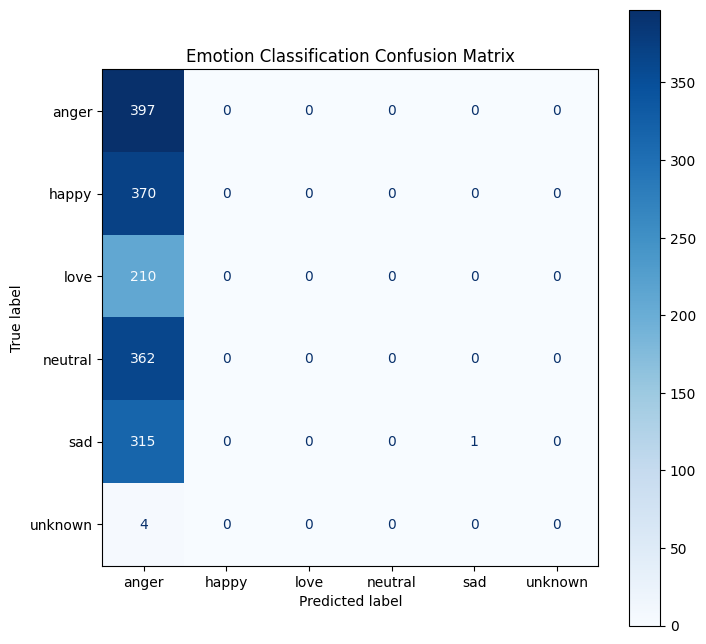

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Print detailed report (Precision, Recall, F1 for EACH emotion)
print("\n--- Detailed Classification Report ---")
# Use label_encoder.classes_ to show actual names like 'anger', 'happy'
print(classification_report(Y_test, y_pred, target_names=label_encoder.classes_))

# 2. Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(Y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Emotion Classification Confusion Matrix')
plt.show()

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/fine_tuned_xlm_roberta"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)





Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)
sentences =[ "مرد وہی ہوتا ہے جو عورتوں کی عزت کرے",
           "جس انسان نے مجھے جیتے جی مار دیا, اسے جینے کی دعا دو. دیکھو",
             "میں آج بہت خوش ہوں کیونکہ میرا کام مکمل ہو گیا ہے",
             "تمہارے لیے میرے دل میں بہت پیار ہے",
             "وہ کل بازار گیا تھا"]

results = classifier(sentences)

for s, r in zip(sentences, results):
    print(f"Sentence: {s}")
    print(f"Prediction: {r}")
    print()

Sentence: مرد وہی ہوتا ہے جو عورتوں کی عزت کرے
Prediction: {'label': 'anger', 'score': 0.21718016266822815}

Sentence: جس انسان نے مجھے جیتے جی مار دیا, اسے جینے کی دعا دو. دیکھو
Prediction: {'label': 'anger', 'score': 0.21718016266822815}

Sentence: میں آج بہت خوش ہوں کیونکہ میرا کام مکمل ہو گیا ہے
Prediction: {'label': 'anger', 'score': 0.21718016266822815}

Sentence: تمہارے لیے میرے دل میں بہت پیار ہے
Prediction: {'label': 'anger', 'score': 0.21718016266822815}

Sentence: وہ کل بازار گیا تھا
Prediction: {'label': 'anger', 'score': 0.21718016266822815}

